# E-Commerce Business Insights

## Olist E-Commerce Analytics Project

This notebook presents the key business insights, opportunities, and recommendations derived from the analysis of the Olist Brazilian e-commerce dataset.

The analysis focuses on:

- Sales performance
- Customer behavior and retention
- RFM customer segmentation
- Product and category performance
- Delivery performance
- Customer satisfaction
- Business opportunities and recommendations

# 1. Executive Summary

The analysis of the Olist e-commerce dataset provides insights into sales performance, customer behavior, product performance, delivery operations, and customer satisfaction.

### Key areas identified

- Sales performance and order trends were analyzed to understand overall business activity.
- Customer purchasing behavior was analyzed using repeat-purchase metrics and RFM segmentation.
- Product and category analysis identified the categories contributing most to sales.
- Delivery performance was evaluated using delivery time, late-delivery rate, and estimated delivery dates.
- Customer satisfaction was evaluated using review scores.
- The relationship between delivery performance and customer reviews was examined to identify operational opportunities.

### Key Business Opportunity

Customer segmentation indicates that a substantial portion of customers falls into the **At Risk** segment. This represents an important retention opportunity, as improving engagement and encouraging repeat purchases from these customers could help protect existing customer value.

The analysis also highlights the importance of delivery performance because late deliveries can be associated with lower customer satisfaction.

# 2. Key Business KPIs

In [6]:
import pandas as pd

# Load cleaned datasets
orders = pd.read_csv(
    "../data/cleaned/olist_orders_clean.csv",
    parse_dates=[
        'order_purchase_timestamp',
        'order_approved_at',
        'order_delivered_carrier_date',
        'order_delivered_customer_date',
        'order_estimated_delivery_date'
    ]
)

customers = pd.read_csv(
    "../data/cleaned/olist_customers_clean.csv"
)

payments = pd.read_csv(
    "../data/cleaned/olist_order_payments_clean.csv"
)

reviews = pd.read_csv(
    "../data/cleaned/olist_order_reviews_clean.csv"
)

# -------------------------
# Sales KPIs
# -------------------------

total_orders = orders['order_id'].nunique()

total_customers = customers['customer_unique_id'].nunique()

payment_summary = (
    payments
    .groupby('order_id')['payment_value']
    .sum()
)

total_payment = payment_summary.sum()

average_order_value = payment_summary.mean()

# -------------------------
# Repeat Customer Rate
# -------------------------

customer_order_counts = (
    orders
    .merge(
        customers[['customer_id', 'customer_unique_id']],
        on='customer_id',
        how='left'
    )
    .groupby('customer_unique_id')['order_id']
    .nunique()
)

repeat_customer_rate = (
    (customer_order_counts > 1).sum()
    / len(customer_order_counts)
) * 100

# -------------------------
# Cancellation Rate
# -------------------------

cancellation_rate = (
    (orders['order_status'] == 'canceled').sum()
    / len(orders)
) * 100

# -------------------------
# Delivery Performance
# -------------------------

delivered = orders[
    orders['order_status'] == 'delivered'
].copy()

delivered['delivery_delay_days'] = (
    delivered['order_delivered_customer_date']
    - delivered['order_estimated_delivery_date']
).dt.days

late_delivery_rate = (
    (delivered['delivery_delay_days'] > 0).sum()
    / len(delivered)
) * 100

# -------------------------
# Review Score
# -------------------------

average_review = reviews['review_score'].mean()

# -------------------------
# KPI Table
# -------------------------

kpi_df = pd.DataFrame({
    'KPI': [
        'Total Orders',
        'Total Customers',
        'Total Payment Value',
        'Average Order Value',
        'Repeat Customer Rate',
        'Cancellation Rate',
        'Late Delivery Rate',
        'Average Review Score'
    ],
    'Value': [
        total_orders,
        total_customers,
        total_payment,
        average_order_value,
        repeat_customer_rate,
        cancellation_rate,
        late_delivery_rate,
        average_review
    ]
})

kpi_df

,KPI,Value
0,Total Orders,9.944100e+04
1,Total Customers,9.609600e+04
2,Total Payment Value,1.600887e+07
3,Average Order Value,1.609903e+02
4,Repeat Customer Rate,3.118756e+00
5,Cancellation Rate,6.285134e-01
6,Late Delivery Rate,6.772528e+00
7,Average Review Score,4.086421e+00


### KPI Interpretation

These KPIs provide a high-level view of the platform's sales volume, customer retention, operational performance, and customer satisfaction.

The metrics also establish a baseline for identifying areas where the business can improve customer retention, delivery performance, and overall customer experience.

# 3. Sales Insights

Sales performance was analyzed using order volume, payment value, average order value, monthly trends, and order status.

The monthly trend helps identify changes in purchasing activity over time, while order status analysis highlights the proportion of successful, canceled, and other order outcomes.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

orders = pd.read_csv(
    "../data/cleaned/olist_orders_clean.csv",
    parse_dates=[
        'order_purchase_timestamp',
        'order_approved_at',
        'order_delivered_carrier_date',
        'order_delivered_customer_date',
        'order_estimated_delivery_date'
    ]
)

payments = pd.read_csv(
    "../data/cleaned/olist_order_payments_clean.csv"
)

In [4]:
sales_data = orders.merge(
    payments.groupby('order_id')['payment_value']
    .sum()
    .reset_index(name='total_payment'),
    on='order_id',
    how='left'
)

sales_data['purchase_month'] = (
    sales_data['order_purchase_timestamp'].dt.to_period('M')
)

monthly_sales = (
    sales_data
    .groupby('purchase_month')
    .agg(
        orders=('order_id', 'nunique'),
        payment_value=('total_payment', 'sum')
    )
    .reset_index()
)

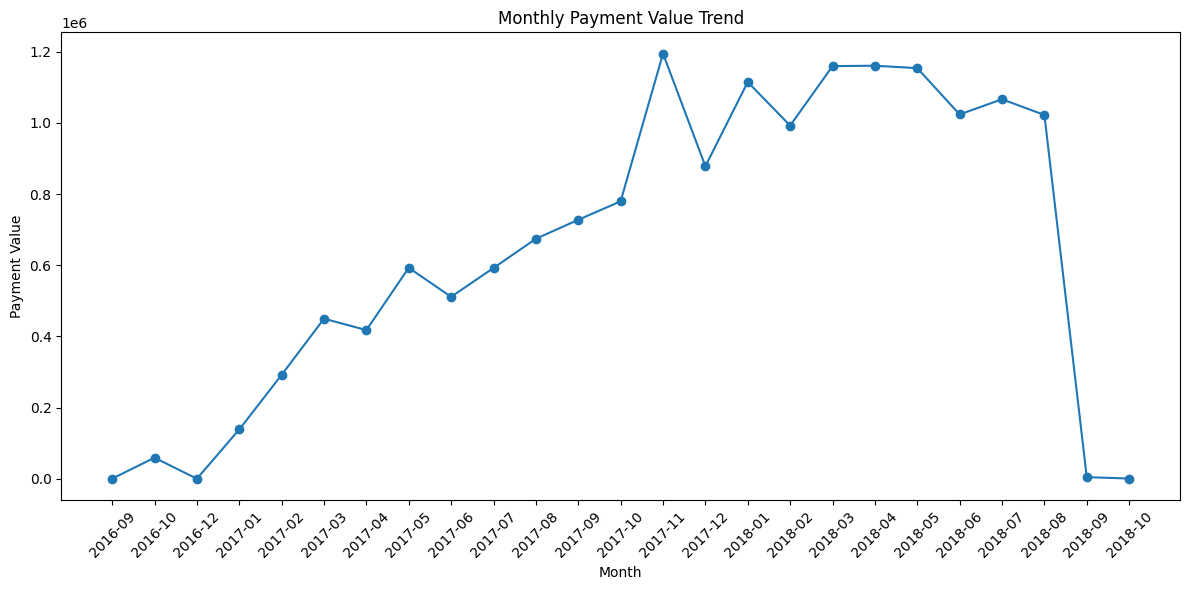

In [7]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_sales['purchase_month'].astype(str),
    monthly_sales['payment_value'],
    marker='o'
)

plt.title('Monthly Payment Value Trend')
plt.xlabel('Month')
plt.ylabel('Payment Value')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Order Status Analysis

Order status provides an overview of successful, canceled, and other order outcomes. This helps identify potential operational issues that may affect overall business performance.

In [9]:
status_summary = (
    orders
    .groupby('order_status')
    .agg(
        orders=('order_id', 'nunique')
    )
    .reset_index()
)

status_summary['percentage'] = (
    status_summary['orders']
    / status_summary['orders'].sum()
) * 100

status_summary

,order_status,orders,percentage
0,approved,2,0.002011
1,canceled,625,0.628513
2,created,5,0.005028
3,delivered,96478,97.020344
4,invoiced,314,0.315765
5,processing,301,0.302692
6,shipped,1107,1.113223
7,unavailable,609,0.612423


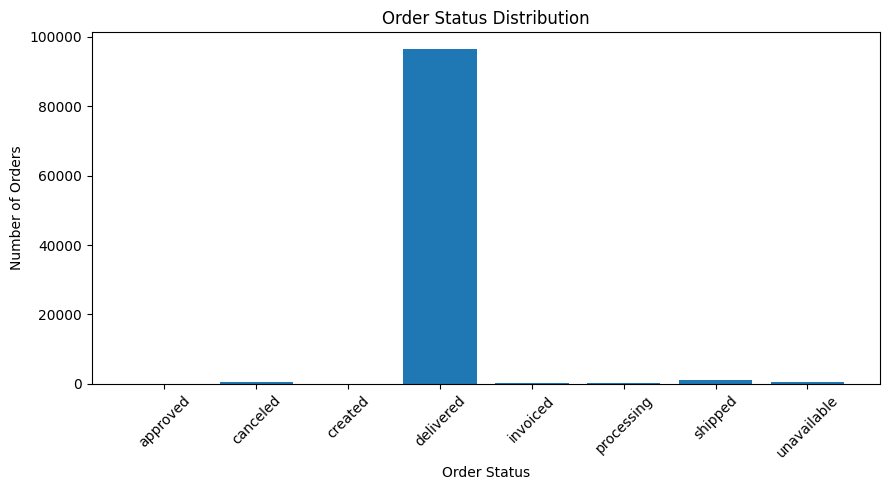

In [10]:
plt.figure(figsize=(9, 5))

plt.bar(
    status_summary['order_status'],
    status_summary['orders']
)

plt.title('Order Status Distribution')
plt.xlabel('Order Status')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Business Interpretation

Order status analysis helps identify the proportion of orders that successfully reach completion and the share that are canceled or remain in other states.

A high concentration of completed orders indicates stable order fulfillment, while canceled or unresolved orders represent potential areas for operational improvement.

# 4. Customer Insights

Customer behavior was analyzed to understand customer retention, purchasing frequency, and the distribution between one-time and repeat customers.

In [12]:
customer_orders = (
    orders
    .merge(
        customers[['customer_id', 'customer_unique_id']],
        on='customer_id',
        how='left'
    )
)

customer_order_counts = (
    customer_orders
    .groupby('customer_unique_id')
    .agg(
        order_count=('order_id', 'nunique')
    )
    .reset_index()
)

customer_order_counts['customer_type'] = customer_order_counts[
    'order_count'
].apply(
    lambda x: 'Repeat Customer' if x > 1 else 'One-time Customer'
)

customer_type_summary = (
    customer_order_counts['customer_type']
    .value_counts()
    .reset_index()
)

customer_type_summary.columns = [
    'customer_type',
    'customers'
]

customer_type_summary['percentage'] = (
    customer_type_summary['customers']
    / customer_type_summary['customers'].sum()
) * 100

customer_type_summary

,customer_type,customers,percentage
0,One-time Customer,93099,96.881244
1,Repeat Customer,2997,3.118756


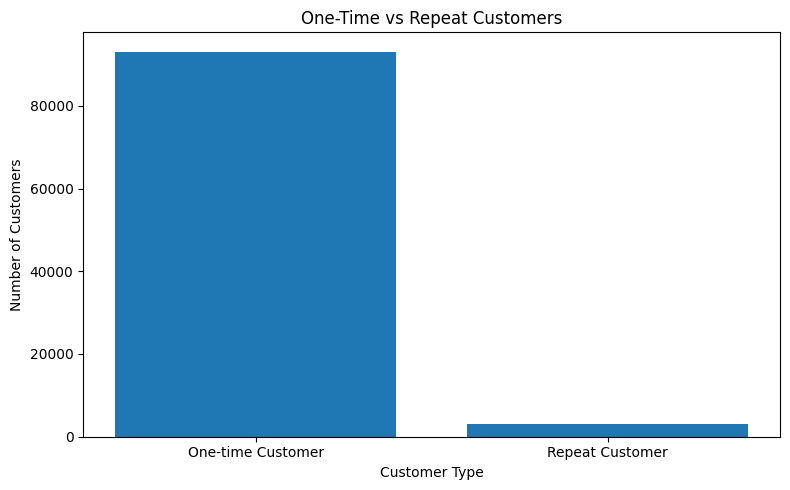

In [13]:
plt.figure(figsize=(8, 5))

plt.bar(
    customer_type_summary['customer_type'],
    customer_type_summary['customers']
)

plt.title('One-Time vs Repeat Customers')
plt.xlabel('Customer Type')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

### Business Interpretation

The comparison between one-time and repeat customers provides an indication of customer retention.

A larger share of one-time customers suggests an opportunity to improve customer retention and encourage additional purchases through targeted engagement, personalized offers, and post-purchase communication.

#RFM
# 5. RFM Customer Segmentation

RFM analysis segments customers based on three dimensions:

- **Recency:** How recently the customer made a purchase
- **Frequency:** How often the customer purchased
- **Monetary:** How much the customer spent

This helps identify high-value, loyal, and at-risk customer groups.

In [14]:
analysis_date = (
    customer_orders['order_purchase_timestamp'].max()
    + pd.Timedelta(days=1)
)

customer_orders = customer_orders.merge(
    payment_summary.rename('total_payment'),
    on='order_id',
    how='left'
)

rfm = (
    customer_orders
    .groupby('customer_unique_id')
    .agg(
        recency=('order_purchase_timestamp',
                 lambda x: (analysis_date - x.max()).days),
        frequency=('order_id', 'nunique'),
        monetary=('total_payment', 'sum')
    )
    .reset_index()
)

In [15]:
rfm['R_score'] = pd.qcut(
    rfm['recency'],
    5,
    labels=[5, 4, 3, 2, 1]
)

rfm['F_score'] = pd.qcut(
    rfm['frequency'].rank(method='first'),
    5,
    labels=[1, 2, 3, 4, 5]
)

rfm['M_score'] = pd.qcut(
    rfm['monetary'],
    5,
    labels=[1, 2, 3, 4, 5]
)

rfm[['R_score', 'F_score', 'M_score']] = (
    rfm[['R_score', 'F_score', 'M_score']].astype(int)
)

In [16]:
def rfm_segment(row):
    if row['R_score'] >= 4 and row['F_score'] >= 4 and row['M_score'] >= 4:
        return 'High Value'
    elif row['R_score'] >= 4 and row['F_score'] >= 3:
        return 'Loyal / Active'
    elif row['R_score'] >= 4 and row['M_score'] >= 3:
        return 'Potential Loyalist'
    elif row['R_score'] <= 2 and row['F_score'] >= 3:
        return 'At Risk'
    elif row['R_score'] <= 2 and row['M_score'] >= 3:
        return 'High Value At Risk'
    else:
        return 'Other'

rfm['segment'] = rfm.apply(rfm_segment, axis=1)

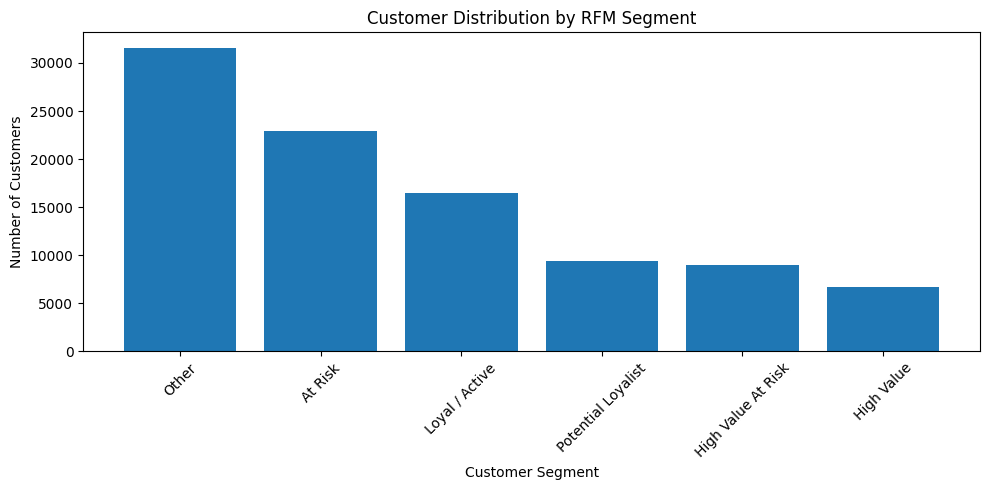

In [17]:
segment_summary = (
    rfm['segment']
    .value_counts()
    .reset_index()
)

segment_summary.columns = ['segment', 'customers']

plt.figure(figsize=(10, 5))

plt.bar(
    segment_summary['segment'],
    segment_summary['customers']
)

plt.title('Customer Distribution by RFM Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Business Interpretation

RFM segmentation identifies different customer groups based on their purchasing behavior.

High-value customers represent an important group for retention and loyalty initiatives, while At Risk and High Value At Risk customers represent potential retention opportunities.

The segmentation can help prioritize marketing efforts according to customer value and engagement.

# 6. Product & Category Insights

Product and category performance was analyzed to identify the products and categories contributing most to sales.

The analysis uses delivered orders and product-level prices to avoid attributing an entire order's payment value to individual products.

In [18]:
order_items = pd.read_csv(
    "../data/cleaned/olist_order_items_clean.csv"
)

products = pd.read_csv(
    "../data/cleaned/olist_products_clean.csv"
)

category_translation = pd.read_csv(
    "../data/cleaned/product_category_name_translation_clean.csv"
)

In [19]:
delivered_order_ids = orders.loc[
    orders['order_status'] == 'delivered',
    'order_id'
]

delivered_items = order_items[
    order_items['order_id'].isin(delivered_order_ids)
].copy()

product_sales = delivered_items.merge(
    products[
        ['product_id', 'product_category_name']
    ],
    on='product_id',
    how='left'
)

product_sales = product_sales.merge(
    category_translation[
        [
            'product_category_name',
            'product_category_name_english'
        ]
    ],
    on='product_category_name',
    how='left'
)

In [20]:
category_sales = (
    product_sales
    .groupby('product_category_name_english')
    .agg(
        items_sold=('order_item_id', 'count'),
        revenue=('price', 'sum'),
        average_price=('price', 'mean')
    )
    .reset_index()
    .sort_values('revenue', ascending=False)
)

category_sales.head(10)

,product_category_name_english,items_sold,revenue,average_price
43,health_beauty,9465,1233131.72,130.283330
70,watches_gifts,5859,1166176.98,199.040276
7,bed_bath_table,10953,1023434.76,93.438762
65,sports_leisure,8431,954852.55,113.254958
15,computers_accessories,7644,888724.61,116.264339
39,furniture_decor,8160,711927.69,87.246040
49,housewares,6795,615628.69,90.600249
20,cool_stuff,3718,610204.10,164.121598
5,auto,4140,578966.65,139.847017
69,toys,4030,471286.48,116.944536


### Business Interpretation

The category analysis identifies the product categories contributing the most merchandise revenue among delivered orders.

The concentration of revenue across leading categories can help the business prioritize inventory planning, category-level promotions, and merchandising strategies.

# 7. Delivery & Customer Satisfaction

Delivery performance was evaluated using delivery duration and delivery delay relative to the estimated delivery date.

Customer satisfaction was evaluated using review scores to understand whether delivery performance is associated with customer experience.

In [21]:
delivered['delivery_days'] = (
    delivered['order_delivered_customer_date']
    - delivered['order_purchase_timestamp']
).dt.days

delivered['is_late'] = (
    delivered['delivery_delay_days'] > 0
)

delivery_summary = (
    delivered[['delivery_days', 'delivery_delay_days']]
    .describe()
)

delivery_summary

,delivery_days,delivery_delay_days
count,96470.000000,96470.000000
mean,12.093604,-11.875889
std,9.551380,10.182105
min,0.000000,-147.000000
25%,6.000000,-17.000000
50%,10.000000,-12.000000
75%,15.000000,-7.000000
max,209.000000,188.000000


In [22]:
late_delivery_rate = (
    delivered['is_late'].sum()
    / len(delivered)
) * 100

print(f"Late delivery rate: {late_delivery_rate:.2f}%")

Late delivery rate: 6.77%


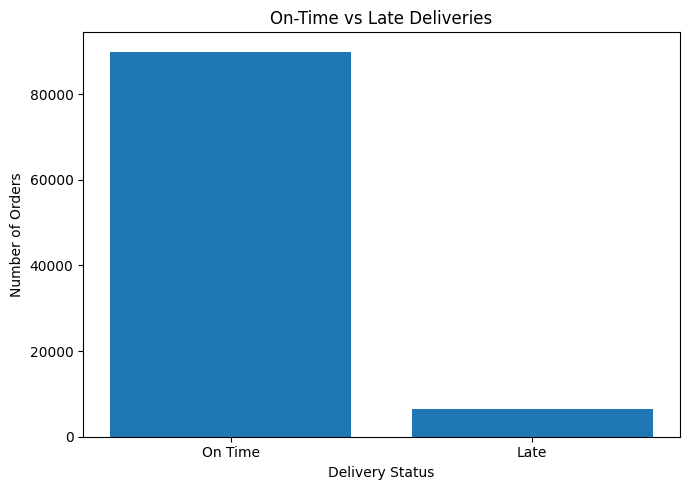

In [23]:
delivery_status = (
    delivered['is_late']
    .value_counts()
    .rename(index={
        False: 'On Time',
        True: 'Late'
    })
    .reset_index()
)

delivery_status.columns = [
    'delivery_status',
    'orders'
]

plt.figure(figsize=(7, 5))

plt.bar(
    delivery_status['delivery_status'],
    delivery_status['orders']
)

plt.title('On-Time vs Late Deliveries')
plt.xlabel('Delivery Status')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.show()

In [24]:
delivery_review_data = delivered.merge(
    reviews[
        ['order_id', 'review_score']
    ],
    on='order_id',
    how='left'
)

delivery_reviews = (
    delivery_review_data
    .groupby('is_late')
    .agg(
        orders=('order_id', 'nunique'),
        average_review_score=('review_score', 'mean')
    )
    .reset_index()
)

delivery_reviews['delivery_status'] = (
    delivery_reviews['is_late']
    .map({
        False: 'On Time',
        True: 'Late'
    })
)

delivery_reviews

,is_late,orders,average_review_score,delivery_status
0,False,89944,4.289999,On Time
1,True,6534,2.271025,Late


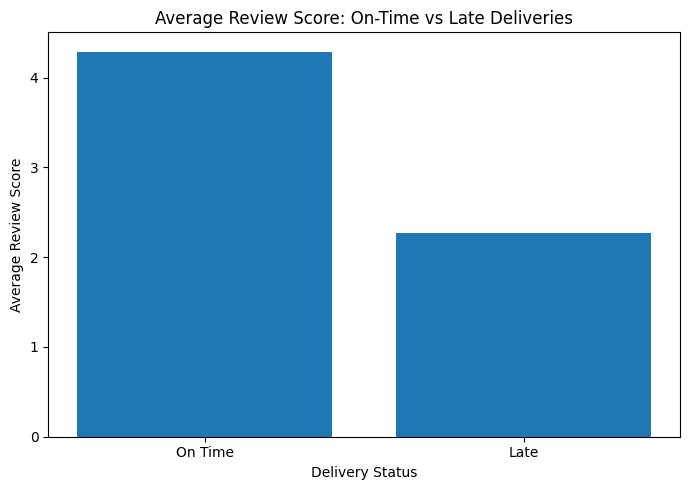

In [25]:
plt.figure(figsize=(7, 5))

plt.bar(
    delivery_reviews['delivery_status'],
    delivery_reviews['average_review_score']
)

plt.title('Average Review Score: On-Time vs Late Deliveries')
plt.xlabel('Delivery Status')
plt.ylabel('Average Review Score')
plt.tight_layout()
plt.show()

### Business Interpretation

Delivery performance is an important component of the customer experience.

Comparing review scores between on-time and late deliveries helps identify whether delivery delays are associated with differences in customer satisfaction.

If late deliveries show lower average review scores, improving delivery reliability represents a potential opportunity to improve customer experience.

# 8. Business Opportunities

The analysis highlights several areas where the business can improve customer retention, customer experience, and sales performance.

### Key opportunities

1. **Customer Retention**
   - The RFM analysis identifies a substantial At Risk customer segment.
   - Targeted retention campaigns can be used to encourage these customers to purchase again.

2. **High-Value Customer Retention**
   - High Value customers have relatively high spending per customer.
   - Loyalty programs and personalized offers can help retain this segment.

3. **Delivery Performance**
   - Late deliveries represent an operational opportunity.
   - Improving delivery reliability may contribute to better customer satisfaction.

4. **Category-Level Optimization**
   - Revenue is concentrated among leading product categories.
   - Inventory, promotions, and merchandising can be prioritized around high-performing categories while exploring opportunities in weaker categories.

5. **Repeat Purchasing**
   - The difference between one-time and repeat customers highlights the opportunity to convert more first-time buyers into repeat customers.

# 9. Business Recommendations

Based on the analysis, the following actions are recommended:

### 1. Launch targeted retention campaigns
Focus on At Risk and High Value At Risk customers using personalized discounts, product recommendations, and re-engagement campaigns.

### 2. Strengthen high-value customer loyalty
Provide loyalty benefits, personalized recommendations, and exclusive promotions to high-value customers.

### 3. Improve delivery reliability
Identify operational causes of late deliveries and prioritize improvements in logistics and fulfillment.

### 4. Increase repeat purchases
Use post-purchase communication, personalized recommendations, and targeted offers to encourage one-time customers to return.

### 5. Optimize category strategy
Use category-level revenue performance to guide inventory planning, promotions, and merchandising decisions.

# 10. Conclusion

The analysis demonstrates how e-commerce data can be transformed into actionable business insights across sales, customers, products, delivery, and customer satisfaction.

Customer segmentation highlights retention opportunities, while product and category analysis provides direction for sales and merchandising decisions. Delivery and review analysis further emphasizes the importance of operational performance in customer experience.

Overall, the analysis provides a data-driven foundation for improving customer retention, operational efficiency, and business performance.